In [13]:
#Librerias
#!pip install pandas numpy matplotlib seaborn scikit-learn imblearn xgboost tensorflow


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

data = pd.read_csv("Datasetcompleto.csv")

# Columnas irrelevantes
data = data.drop(['Source', 'Destination', 'Info', 'Label', 'Source port', 'Destination port'], axis=1)

C:\Users\User\AppData\Local\Temp\ipykernel_23372\411581683.py:11: DtypeWarning: Columns (0: TCP Flags, 1: TCP Syn, 2: TCP ACK, 3: TCP FIN, 4: TCP RST, 5: TCP PSH, 6: TCP URG, 7: ICMP Checksum, 8: ICMP Sequence Number) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Datasetcompleto.csv")


In [15]:
print(data.dtypes)

Duration                float64
Protocol                    str
Length                    int64
TCP Flags                object
TCP Syn                  object
TCP ACK                  object
TCP FIN                  object
TCP RST                  object
TCP PSH                  object
TCP URG                  object
TCP Window Size           int64
TCP Sequence Number       int64
ICMP Type                 int64
ICMP Checksum            object
ICMP Sequence Number     object
Attack Category             str
dtype: object


In [16]:
# Separar features y target
X = data.drop('Attack Category', axis=1)
y = data['Attack Category']

# Division de dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Tamaños
print("Tamaño Train:", X_train.shape)
print("Tamaño Test:", X_test.shape)

# Distribucion de clases
print("Distribución Train:\n", y_train.value_counts())
print("Distribución Test:\n", y_test.value_counts())

Tamaño Train: (51087, 15)
Tamaño Test: (21895, 15)
Distribución Train:
 Attack Category
DoS                   22994
Port scan             12636
Vulnerability scan    12435
Normal                 3022
Name: count, dtype: int64
Distribución Test:
 Attack Category
DoS                   9855
Port scan             5416
Vulnerability scan    5329
Normal                1295
Name: count, dtype: int64


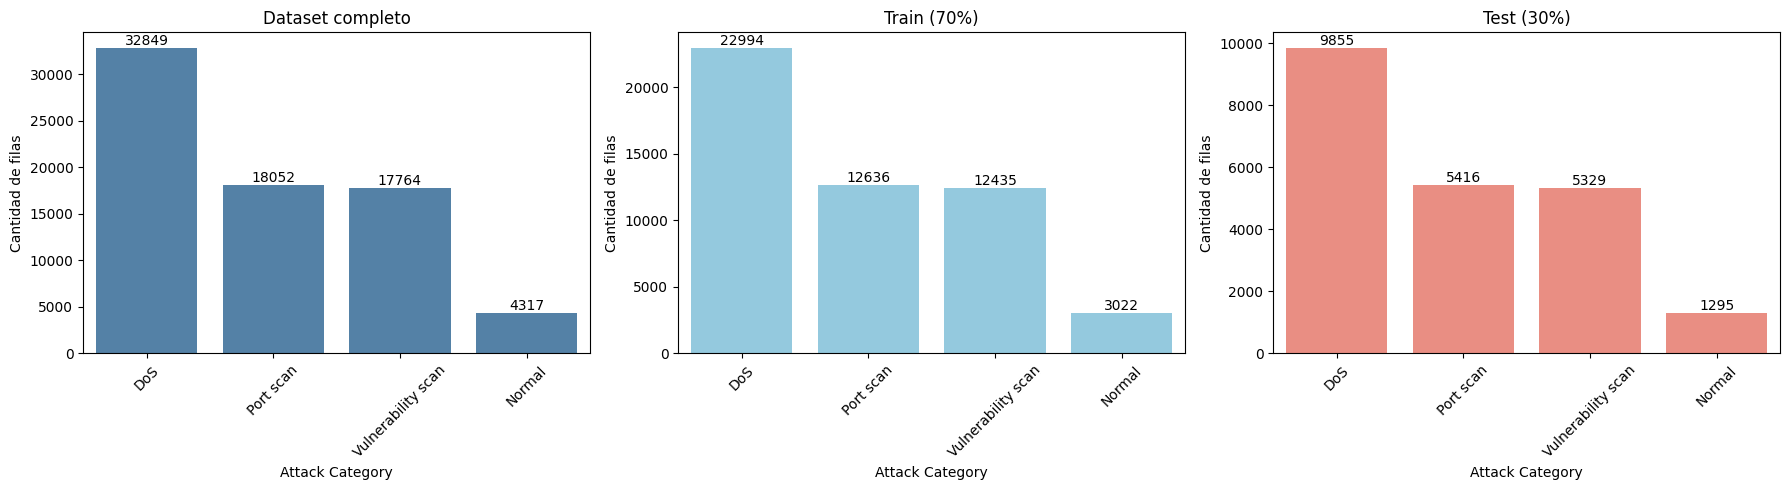

In [17]:
original_counts = y.value_counts()
train_counts = y_train.value_counts()
test_counts = y_test.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, counts, title, color in zip(
    axes,
    [original_counts, train_counts, test_counts],
    ['Dataset completo', 'Train (70%)', 'Test (30%)'],
    ['steelblue', 'skyblue', 'salmon']
):
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color=color)
    ax.set_title(title)
    ax.set_ylabel('Cantidad de filas')
    
    plt.setp(ax.get_xticklabels(), rotation=45)
    
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.01, str(v), ha='center')

plt.tight_layout()
plt.show()


In [18]:
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Columnas
num_cols = [
    'Duration', 'Length', 'TCP Window Size', 'TCP Sequence Number'
]

tcp_flags = [
    'TCP Syn', 'TCP ACK', 'TCP FIN', 'TCP RST', 'TCP PSH', 'TCP URG',
]

cat_cols = ['Protocol', 'ICMP Type']

features = num_cols + tcp_flags + cat_cols 

# Flags TCP a 0/1
def convert_flag(val):
    return 1 if str(val).strip() in ['1', 'True', 'true'] else 0
    
for col in tcp_flags:
    X_train[col] = X_train[col].apply(convert_flag)
    X_test[col] = X_test[col].apply(convert_flag)

# Codificar columnas categóricas
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    le_dict[col] = le

# Escalamiento
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Balanceo con SMOTETomek
print("Distribución original en y_train:\n", y_train.value_counts())

# Aplicar SMOTETomek 
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train[features], y_train)

print("\nDistribución balanceada en y_train_res:\n", y_train_res.value_counts())
print("\nTamaño X_train_res:", X_train_res.shape)
print("Tamaño X_test:", X_test[features].shape)


Distribución original en y_train:
 Attack Category
DoS                   22994
Port scan             12636
Vulnerability scan    12435
Normal                 3022
Name: count, dtype: int64

Distribución balanceada en y_train_res:
 Attack Category
DoS                   22994
Normal                22994
Port scan             22616
Vulnerability scan    22616
Name: count, dtype: int64

Tamaño X_train_res: (91220, 12)
Tamaño X_test: (21895, 12)


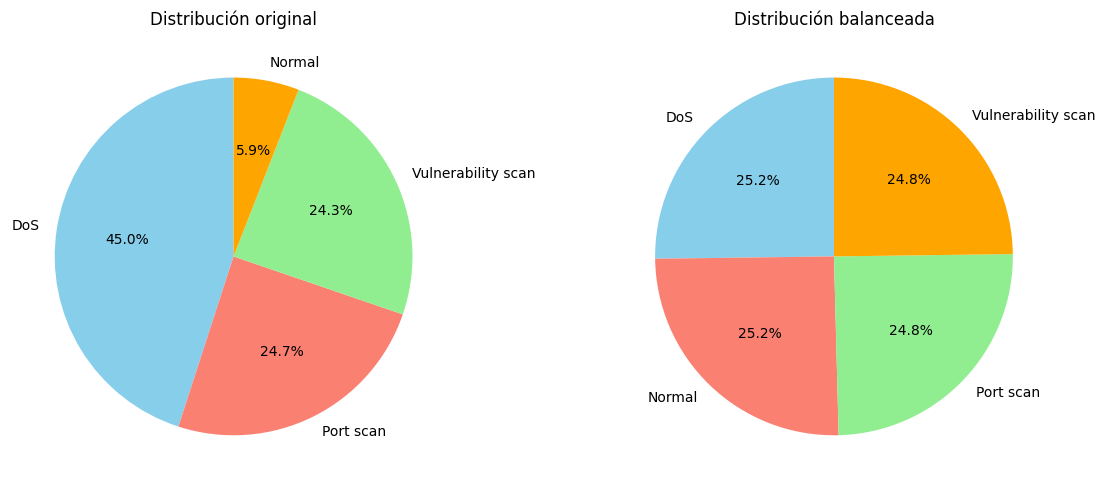

In [19]:
import matplotlib.pyplot as plt

# Clases
balanced_counts = pd.Series(y_train_res).value_counts()

# Distribución original
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.pie(
    original_counts.values, 
    labels=original_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['skyblue', 'salmon', 'lightgreen', 'orange']
)
plt.title("Distribución original")

# Distribución balanceada
plt.subplot(1,2,2)
plt.pie(
    balanced_counts.values, 
    labels=balanced_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['skyblue', 'salmon', 'lightgreen', 'orange']
)
plt.title("Distribución balanceada")

plt.tight_layout()
plt.show()


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Codificar target
le_attack = LabelEncoder()
y_train_res_enc = le_attack.fit_transform(y_train_res)
y_test_enc = le_attack.transform(y_test)


In [21]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=300, max_depth=12, max_features=0.5, min_samples_leaf=2, min_samples_split=2, n_jobs=-1) 
rf_model.fit(X_train_res, y_train_res_enc)
y_pred_rf = rf_model.predict(X_test[features])

# XGBoost
xgb_model = XGBClassifier(random_state=42, n_estimators=400, max_depth=8, gamma=0.3, learning_rate=0.03, n_jobs=-1)
xgb_model.fit(X_train_res, y_train_res_enc)
y_pred_xgb = xgb_model.predict(X_test[features])

# Regresion logistica
lr_model = LogisticRegression(
    random_state=42,
    max_iter=2000,
    C=5.0,                 # menos regularización → más flexible
    solver='saga',         # mejor para datasets grandes
    penalty='l2',          # puedes probar también 'l1'
    class_weight='balanced',  # clave si hay desbalance
    n_jobs=-1
)

lr_model.fit(X_train_res, y_train_res_enc)
y_pred_lr = lr_model.predict(X_test[features])

# SVM
svm_model = SVC(
    kernel='rbf',
    C=10,                 # MÁS importante
    gamma=0.01,           # controla complejidad
    class_weight='balanced',
    probability=True      # útil para métricas ROC
)
svm_model.fit(X_train_res, y_train_res_enc)
y_pred_svm = svm_model.predict(X_test[features])

c:\Users\User\anaconda3\envs\Semi\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


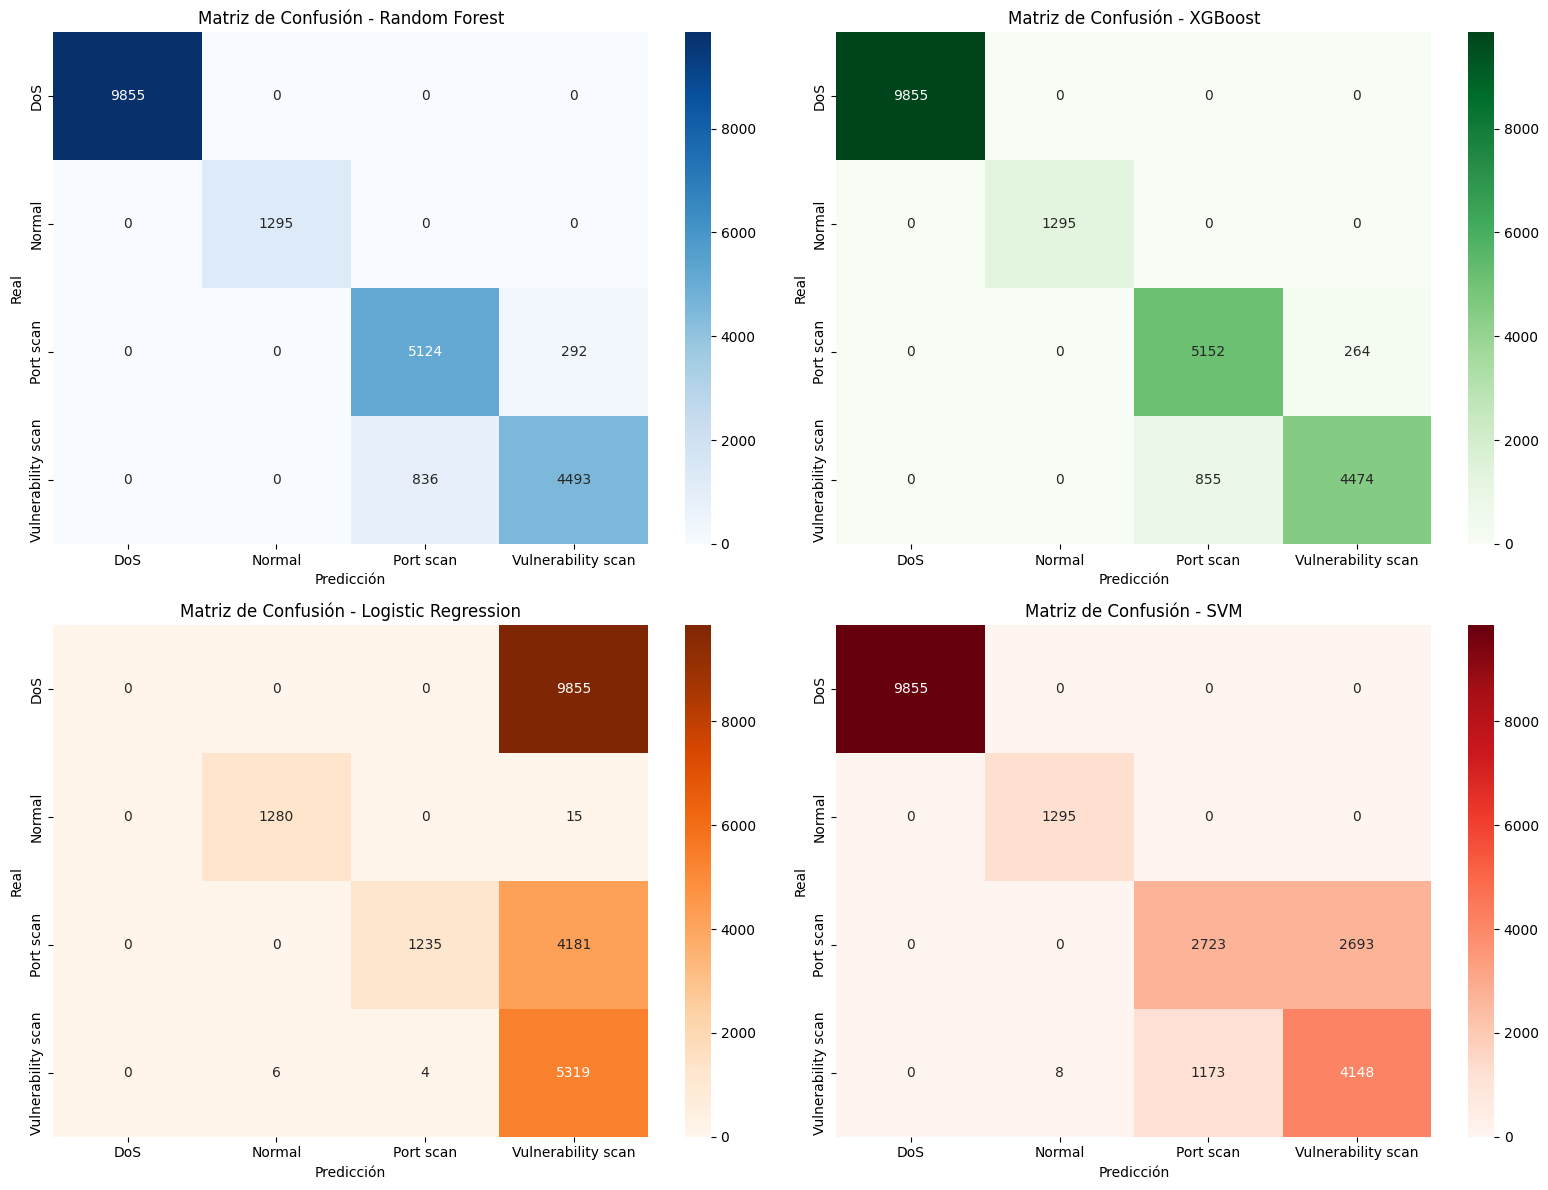

In [22]:
# Matrices de confusion
cm_rf = confusion_matrix(y_test_enc, y_pred_rf)
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)
cm_lr = confusion_matrix(y_test_enc, y_pred_lr)
cm_svm = confusion_matrix(y_test_enc, y_pred_svm)

# 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_attack.classes_, yticklabels=le_attack.classes_, ax=axes[0, 0])
axes[0, 0].set_title("Matriz de Confusión - Random Forest")
axes[0, 0].set_xlabel("Predicción")
axes[0, 0].set_ylabel("Real")

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_attack.classes_, yticklabels=le_attack.classes_, ax=axes[0, 1])
axes[0, 1].set_title("Matriz de Confusión - XGBoost")
axes[0, 1].set_xlabel("Predicción")
axes[0, 1].set_ylabel("Real")

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_attack.classes_, yticklabels=le_attack.classes_, ax=axes[1, 0])
axes[1, 0].set_title("Matriz de Confusión - Logistic Regression")
axes[1, 0].set_xlabel("Predicción")
axes[1, 0].set_ylabel("Real")

# SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le_attack.classes_, yticklabels=le_attack.classes_, ax=axes[1, 1])
axes[1, 1].set_title("Matriz de Confusión - SVM")
axes[1, 1].set_xlabel("Predicción")
axes[1, 1].set_ylabel("Real")

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metricas de modelos
def mostrar_metricas(nombre_modelo, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n Métricas Totales - {nombre_modelo}")
    print(f" Accuracy:  {accuracy:.6f}")
    print(f" Precision: {precision:.6f}")
    print(f" Recall:    {recall:.6f}")
    print(f" F1-score:  {f1:.6f}")

# Métricas para Random Forest
mostrar_metricas("Random Forest", y_test_enc, y_pred_rf)

# Métricas para XGBoost
mostrar_metricas("XGBoost", y_test_enc, y_pred_xgb)

# Métricas para Regresion logistica
mostrar_metricas("Regresion logistica", y_test_enc, y_pred_lr)

# Métricas para SVM
mostrar_metricas("SVM", y_test_enc, y_pred_svm)


 Métricas Totales - Random Forest
 Accuracy:  0.948481
 Precision: 0.949677
 Recall:    0.947302
 F1-score:  0.947329

 Métricas Totales - XGBoost
 Accuracy:  0.948892
 Precision: 0.950487
 Recall:    0.947703
 F1-score:  0.947721

 Métricas Totales - Regresion logistica
 Accuracy:  0.357799
 Precision: 0.566676
 Recall:    0.553642
 F1-score:  0.448430

 Métricas Totales - SVM
 Accuracy:  0.823065
 Precision: 0.824782
 Recall:    0.820288
 F1-score:  0.815858


c:\Users\User\anaconda3\envs\Semi\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(
max_depth= 12, min_samples_leaf= 2, min_samples_split= 2, n_estimators= 300, max_features= 0.5,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
gamma=0.3, learning_rate= 0.03, max_depth= 8, n_estimators= 400,
        random_state=42,
        n_jobs=-1
    ),
    "Regresion": LogisticRegression(
    random_state=42,
    max_iter=2000,
    C=5.0,                 # menos regularización → más flexible
    solver='saga',         # mejor para datasets grandes
    penalty='l2',          # puedes probar también 'l1'
    class_weight='balanced',  # clave si hay desbalance
    n_jobs=-1
),
    "SVM": SVC(
    kernel='rbf',
    C=10,                 # MÁS importante
    gamma=0.01,           # controla complejidad
    class_weight='balanced',
    probability=True      # útil para métricas ROC
    )
}
cross_val_scores = {}
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_res, y_train_res_enc,
        scoring='recall_macro',
        cv=5,
        
        n_jobs=-1
    )
    cross_val_scores[name] = {
        'media': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"   • {name:<20}: {scores.mean():.4f} (±{scores.std():.4f})")

   • Random Forest       : 0.9502 (±0.0017)
   • XGBoost             : 0.9491 (±0.0017)
   • Regresion           : 0.8497 (±0.0034)
   • SVM                 : 0.8170 (±0.0020)
